# Fat-Tail Option Pricing & Volatility Surface Pipeline

This notebook implements an end-to-end research pipeline:

**option-chain input → strict cleaning → forward/moneyness → market IV → SVI slices → CGMY calibration → Fourier pricing → fitted CGMY IV surface → diagnostics and arbitrage checks.**

The notebook is deliberately configurable. All major assumptions live in `ModelConfig`, so the same pipeline can be run on synthetic data or a real option chain without rewriting model code.

> **Important numerical note:** CGMY calibration is computationally expensive because every objective evaluation requires Fourier integrations. Start with the validation/synthetic workflow, then replace the synthetic input with your real chain.


## 1. Imports

In [1]:
from dataclasses import dataclass, field
from typing import Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq, minimize, differential_evolution
from scipy.integrate import quad
from scipy.special import gamma
from scipy.stats import norm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Fully configurable model configuration

The configuration is split into market assumptions, cleaning rules, SVI settings, CGMY calibration settings, numerical integration settings, and surface-grid settings.

In [2]:
@dataclass
class MarketConfig:
    spot: float = 5000.0
    risk_free_rate: float = 0.040
    dividend_yield: float = 0.015
    valuation_date: str = "2026-10-03"
    day_count: float = 365.25


@dataclass
class CleaningConfig:
    min_maturity: float = 7 / 365.25
    max_maturity: float = 5.0

    min_bid: float = 0.01
    max_bid_ask_spread_pct: float = 0.20

    min_volume: int = 1
    min_open_interest: int = 10

    min_iv: float = 0.01
    max_iv: float = 5.0

    min_log_moneyness: float = -0.50
    max_log_moneyness: float = 0.50

    min_strike_ratio: float = 0.50
    max_strike_ratio: float = 1.50

    min_vega: float = 1e-6
    intrinsic_tolerance: float = 1e-8


@dataclass
class SVIConfig:
    min_observations: int = 5

    parameter_bounds: Tuple = (
        (-1.0, 1.0),       # a
        (1e-8, 10.0),      # b
        (-0.999, 0.999),   # rho
        (-2.0, 2.0),       # m
        (1e-8, 2.0),       # sigma
    )

    optimizer: str = "L-BFGS-B"


@dataclass
class CGMYConfig:
    # C, G, M, Y
    parameter_bounds: Tuple = (
        (1e-5, 5.0),
        (1e-3, 100.0),
        (1e-3, 100.0),
        (0.05, 1.95),
    )

    global_seed: int = 42
    global_maxiter: int = 100
    global_popsize: int = 15
    global_tol: float = 1e-6

    local_maxiter: int = 2000
    local_ftol: float = 1e-12
    local_gtol: float = 1e-8


@dataclass
class NumericalConfig:
    iv_lower_bound: float = 0.01
    iv_upper_bound: float = 5.0

    integration_upper_bound: float = 100.0
    integration_limit: int = 250

    integration_epsabs: float = 1e-7
    integration_epsrel: float = 1e-7

    arbitrage_tolerance: float = 1e-6


@dataclass
class SurfaceConfig:
    min_maturity: float = 0.05
    max_maturity: float = 3.0
    maturity_points: int = 40

    min_log_moneyness: float = -0.40
    max_log_moneyness: float = 0.40
    moneyness_points: int = 81


@dataclass
class ModelConfig:
    market: MarketConfig = field(default_factory=MarketConfig)
    cleaning: CleaningConfig = field(default_factory=CleaningConfig)
    svi: SVIConfig = field(default_factory=SVIConfig)
    cgmy: CGMYConfig = field(default_factory=CGMYConfig)
    numerical: NumericalConfig = field(default_factory=NumericalConfig)
    surface: SurfaceConfig = field(default_factory=SurfaceConfig)


CFG = ModelConfig()
CFG


ModelConfig(market=MarketConfig(spot=5000.0, risk_free_rate=0.04, dividend_yield=0.015, valuation_date='2026-10-03', day_count=365.25), cleaning=CleaningConfig(min_maturity=0.019164955509924708, max_maturity=5.0, min_bid=0.01, max_bid_ask_spread_pct=0.2, min_volume=1, min_open_interest=10, min_iv=0.01, max_iv=5.0, min_log_moneyness=-0.5, max_log_moneyness=0.5, min_strike_ratio=0.5, max_strike_ratio=1.5, min_vega=1e-06, intrinsic_tolerance=1e-08), svi=SVIConfig(min_observations=5, parameter_bounds=((-1.0, 1.0), (1e-08, 10.0), (-0.999, 0.999), (-2.0, 2.0), (1e-08, 2.0)), optimizer='L-BFGS-B'), cgmy=CGMYConfig(parameter_bounds=((1e-05, 5.0), (0.001, 100.0), (0.001, 100.0), (0.05, 1.95)), global_seed=42, global_maxiter=100, global_popsize=15, global_tol=1e-06, local_maxiter=2000, local_ftol=1e-12, local_gtol=1e-08), numerical=NumericalConfig(iv_lower_bound=0.01, iv_upper_bound=5.0, integration_upper_bound=100.0, integration_limit=250, integration_epsabs=1e-07, integration_epsrel=1e-07, arb

## 3. Configuration helper

Use this section to change the experiment without touching the model implementation.

Examples:

```python
CFG.market.spot = 5200
CFG.market.risk_free_rate = 0.035
CFG.cleaning.max_bid_ask_spread_pct = 0.10
CFG.cgmy.global_maxiter = 250
```


In [3]:
def show_config(CFG):
    print("MARKET")
    print(CFG.market)
    print("\nCLEANING")
    print(CFG.cleaning)
    print("\nSVI")
    print(CFG.svi)
    print("\nCGMY")
    print(CFG.cgmy)
    print("\nNUMERICAL")
    print(CFG.numerical)
    print("\nSURFACE")
    print(CFG.surface)


show_config(CFG)


MARKET
MarketConfig(spot=5000.0, risk_free_rate=0.04, dividend_yield=0.015, valuation_date='2026-10-03', day_count=365.25)

CLEANING
CleaningConfig(min_maturity=0.019164955509924708, max_maturity=5.0, min_bid=0.01, max_bid_ask_spread_pct=0.2, min_volume=1, min_open_interest=10, min_iv=0.01, max_iv=5.0, min_log_moneyness=-0.5, max_log_moneyness=0.5, min_strike_ratio=0.5, max_strike_ratio=1.5, min_vega=1e-06, intrinsic_tolerance=1e-08)

SVI
SVIConfig(min_observations=5, parameter_bounds=((-1.0, 1.0), (1e-08, 10.0), (-0.999, 0.999), (-2.0, 2.0), (1e-08, 2.0)), optimizer='L-BFGS-B')

CGMY
CGMYConfig(parameter_bounds=((1e-05, 5.0), (0.001, 100.0), (0.001, 100.0), (0.05, 1.95)), global_seed=42, global_maxiter=100, global_popsize=15, global_tol=1e-06, local_maxiter=2000, local_ftol=1e-12, local_gtol=1e-08)

NUMERICAL
NumericalConfig(iv_lower_bound=0.01, iv_upper_bound=5.0, integration_upper_bound=100.0, integration_limit=250, integration_epsabs=1e-07, integration_epsrel=1e-07, arbitrage_toler

## 4. Black–Scholes utilities

These are used for synthetic-data generation and for converting market option prices into Black–Scholes implied volatility. They are **not** the final fat-tail pricing model.

In [4]:
def black_scholes_call(S, K, T, r, q, sigma):
    if T <= 0:
        return max(S - K, 0.0)

    if sigma <= 0:
        return max(
            S * np.exp(-q * T) - K * np.exp(-r * T),
            0.0
        )

    d1 = (
        np.log(S / K)
        + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * np.exp(-q * T) * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )


def black_scholes_vega(S, K, T, r, q, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0

    d1 = (
        np.log(S / K)
        + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    return (
        S
        * np.exp(-q * T)
        * norm.pdf(d1)
        * np.sqrt(T)
    )


def implied_volatility(price, S, K, T, r, q, lower=0.01, upper=5.0):
    intrinsic = max(
        S * np.exp(-q * T) - K * np.exp(-r * T),
        0.0
    )

    upper_price = S * np.exp(-q * T)

    if not np.isfinite(price):
        return np.nan

    if price < intrinsic - 1e-10:
        return np.nan

    if price > upper_price + 1e-10:
        return np.nan

    def objective(sigma):
        return black_scholes_call(S, K, T, r, q, sigma) - price

    try:
        return brentq(objective, lower, upper)
    except ValueError:
        return np.nan


## 5. Synthetic option-chain generator

The default input is synthetic so the notebook is immediately runnable. The synthetic chain contains a skew/smile, realistic bid/ask spreads, volume/open-interest variation, and optional bad observations for testing the strict cleaner.

In [5]:
def synthetic_iv(K, T, spot, r, q):
    F = spot * np.exp((r - q) * T)
    k = np.log(K / F)

    # Deliberately non-flat surface:
    # negative skew + convex smile + mild term structure
    base_vol = 0.18
    skew = -0.10 * k
    smile = 0.35 * k**2
    term_structure = 0.02 * np.exp(-T)

    return max(
        base_vol + skew + smile + term_structure,
        0.03
    )


def generate_bid_ask(theoretical_price, spread_pct, rng):
    spread = max(theoretical_price * spread_pct, 0.005)

    noise = rng.normal(
        loc=0.0,
        scale=0.10 * spread
    )

    mid = max(
        theoretical_price + noise,
        0.001
    )

    bid = max(mid - spread / 2, 0.0)
    ask = mid + spread / 2

    return bid, ask


def generate_synthetic_chain(CFG, seed=123, add_bad_quotes=True):
    rng = np.random.default_rng(seed)

    S0 = CFG.market.spot
    r = CFG.market.risk_free_rate
    q = CFG.market.dividend_yield
    valuation_date = pd.Timestamp(CFG.market.valuation_date)

    maturities = [
        14 / 365.25,
        30 / 365.25,
        60 / 365.25,
        90 / 365.25,
        180 / 365.25,
        270 / 365.25,
        365 / 365.25,
        2.0,
        3.0
    ]

    records = []

    strikes = S0 * np.linspace(
        CFG.cleaning.min_strike_ratio,
        CFG.cleaning.max_strike_ratio,
        41
    )

    for T in maturities:
        expiration = (
            valuation_date
            + pd.Timedelta(days=int(T * 365.25))
        )

        F = S0 * np.exp((r - q) * T)

        for K in strikes:
            iv = synthetic_iv(K, T, S0, r, q)

            call_price = black_scholes_call(
                S0, K, T, r, q, iv
            )

            put_price = (
                call_price
                - S0 * np.exp(-q * T)
                + K * np.exp(-r * T)
            )

            k = np.log(K / F)

            # Wider spreads in the wings.
            spread_pct = (
                0.008
                + 0.035 * abs(k)
                + 0.005 * np.sqrt(T)
            )

            call_bid, call_ask = generate_bid_ask(
                call_price,
                spread_pct,
                rng
            )

            put_bid, put_ask = generate_bid_ask(
                put_price,
                spread_pct,
                rng
            )

            volume = max(
                1,
                int(rng.lognormal(mean=3.5, sigma=1.0))
            )

            open_interest = max(
                10,
                int(rng.lognormal(mean=5.0, sigma=1.2))
            )

            records.append({
                "expiration": expiration,
                "strike": K,
                "bid": call_bid,
                "ask": call_ask,
                "volume": volume,
                "open_interest": open_interest,
                "option_type": "C"
            })

            records.append({
                "expiration": expiration,
                "strike": K,
                "bid": put_bid,
                "ask": put_ask,
                "volume": volume,
                "open_interest": open_interest,
                "option_type": "P"
            })

    chain = pd.DataFrame(records)

    if add_bad_quotes:
        n_bad = max(1, int(0.01 * len(chain)))
        bad_idx = rng.choice(
            chain.index,
            size=n_bad,
            replace=False
        )

        # Some deliberately invalid observations:
        for i, idx in enumerate(bad_idx):
            if i % 4 == 0:
                chain.loc[idx, "bid"] = -1.0
            elif i % 4 == 1:
                chain.loc[idx, "ask"] = chain.loc[idx, "bid"] * 0.5
            elif i % 4 == 2:
                chain.loc[idx, "bid"] = 0.0
                chain.loc[idx, "ask"] = 0.001
            else:
                chain.loc[idx, "volume"] = 0

    return chain


options_raw = generate_synthetic_chain(CFG, seed=123)

print("Raw observations:", len(options_raw))
display(options_raw.head(10))


Raw observations: 738


,expiration,strike,bid,ask,volume,open_interest,option_type
0,2026-10-16,2500.0,2451.118687,2534.331979,120,187,C
1,2026-10-16,2500.0,0.000000,0.003500,120,187,P
2,2026-10-16,2625.0,2345.548169,2420.551116,17,284,C
3,2026-10-16,2625.0,0.000000,0.003500,17,284,P
4,2026-10-16,2750.0,2215.506489,2282.904232,36,23,C
5,2026-10-16,2750.0,0.000000,0.003500,36,23,P
6,2026-10-16,2875.0,2103.549262,2163.902165,90,174,C
7,2026-10-16,2875.0,0.000000,0.003500,90,174,P
8,2026-10-16,3000.0,1983.054434,2036.883419,24,222,C
9,2026-10-16,3000.0,0.000000,0.003500,24,222,P


## 6. Strict option-chain cleaning

The cleaner enforces data validity, maturity limits, quote consistency, bid/ask spread limits, liquidity limits, forward moneyness limits, no-arbitrage price bounds, and duplicate removal.

In [6]:
def clean_option_chain(options, CFG):
    options = options.copy()

    # ---------- Standardize ----------
    options.columns = (
        options.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_", regex=False)
    )

    required = [
        "expiration",
        "strike",
        "bid",
        "ask",
        "volume",
        "open_interest",
        "option_type"
    ]

    missing = [c for c in required if c not in options.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    options["option_type"] = (
        options["option_type"]
        .astype(str)
        .str.upper()
        .str.strip()
        .replace({"CALL": "C", "PUT": "P"})
    )

    options = options[
        options["option_type"].isin(["C", "P"])
    ].copy()

    # ---------- Dates ----------
    options["expiration"] = pd.to_datetime(
        options["expiration"],
        errors="coerce"
    )

    options = options[
        options["expiration"].notna()
    ].copy()

    valuation_date = pd.Timestamp(
        CFG.market.valuation_date
    )

    options["T"] = (
        options["expiration"] - valuation_date
    ).dt.total_seconds() / (
        CFG.market.day_count * 24 * 3600
    )

    # ---------- Numeric conversion ----------
    numeric_columns = [
        "strike",
        "bid",
        "ask",
        "volume",
        "open_interest"
    ]

    for col in numeric_columns:
        options[col] = pd.to_numeric(
            options[col],
            errors="coerce"
        )

    options = options.dropna(
        subset=numeric_columns + ["T"]
    ).copy()

    # ---------- Maturity ----------
    options = options[
        (options["T"] >= CFG.cleaning.min_maturity)
        & (options["T"] <= CFG.cleaning.max_maturity)
    ].copy()

    # ---------- Basic quote validity ----------
    options = options[options["strike"] > 0].copy()
    options = options[options["bid"] >= 0].copy()
    options = options[options["ask"] >= options["bid"]].copy()
    options = options[options["ask"] > options["bid"]].copy()
    options = options[options["bid"] >= CFG.cleaning.min_bid].copy()

    # ---------- Mid / spread ----------
    options["mid"] = (
        options["bid"] + options["ask"]
    ) / 2

    options["spread"] = (
        options["ask"] - options["bid"]
    )

    options["spread_pct"] = (
        options["spread"] / options["mid"]
    )

    options = options[
        options["spread_pct"]
        <= CFG.cleaning.max_bid_ask_spread_pct
    ].copy()

    # ---------- Liquidity ----------
    options = options[
        options["volume"] >= CFG.cleaning.min_volume
    ].copy()

    options = options[
        options["open_interest"]
        >= CFG.cleaning.min_open_interest
    ].copy()

    # ---------- Forward ----------
    S0 = CFG.market.spot
    r = CFG.market.risk_free_rate
    q = CFG.market.dividend_yield

    options["forward"] = (
        S0
        * np.exp((r - q) * options["T"])
    )

    # ---------- Strike ratio and log moneyness ----------
    options["strike_ratio"] = (
        options["strike"] / options["forward"]
    )

    options = options[
        (options["strike_ratio"]
         >= CFG.cleaning.min_strike_ratio)
        &
        (options["strike_ratio"]
         <= CFG.cleaning.max_strike_ratio)
    ].copy()

    options["log_moneyness"] = np.log(
        options["strike"] / options["forward"]
    )

    options = options[
        (options["log_moneyness"]
         >= CFG.cleaning.min_log_moneyness)
        &
        (options["log_moneyness"]
         <= CFG.cleaning.max_log_moneyness)
    ].copy()

    # ---------- No-arbitrage intrinsic-value bounds ----------
    call_intrinsic = np.maximum(
        S0 * np.exp(-q * options["T"])
        - options["strike"] * np.exp(-r * options["T"]),
        0.0
    )

    put_intrinsic = np.maximum(
        options["strike"] * np.exp(-r * options["T"])
        - S0 * np.exp(-q * options["T"]),
        0.0
    )

    options["intrinsic"] = np.where(
        options["option_type"] == "C",
        call_intrinsic,
        put_intrinsic
    )

    tol = CFG.cleaning.intrinsic_tolerance

    options = options[
        options["mid"] >= options["intrinsic"] - tol
    ].copy()

    # ---------- Upper bounds ----------
    call_upper = S0 * np.exp(-q * options["T"])
    put_upper = options["strike"] * np.exp(-r * options["T"])

    options["upper_bound"] = np.where(
        options["option_type"] == "C",
        call_upper,
        put_upper
    )

    options = options[
        options["mid"] <= options["upper_bound"] + tol
    ].copy()

    # ---------- Put-call parity: convert puts to synthetic calls ----------
    options["call_price"] = np.where(
        options["option_type"] == "C",
        options["mid"],
        options["mid"]
        + S0 * np.exp(-q * options["T"])
        - options["strike"] * np.exp(-r * options["T"])
    )

    options = options[
        options["call_price"] > 0
    ].copy()

    # ---------- Duplicate contracts ----------
    options = options.drop_duplicates(
        subset=["expiration", "strike", "option_type"],
        keep="last"
    )

    return options.reset_index(drop=True)


options = clean_option_chain(
    options_raw,
    CFG
)

print("Raw observations:", len(options_raw))
print("Clean observations:", len(options))
print("Removed:", len(options_raw) - len(options))

display(options.head())


Raw observations: 738
Clean observations: 536
Removed: 202


,expiration,strike,bid,ask,volume,open_interest,option_type,T,mid,spread,spread_pct,forward,strike_ratio,log_moneyness,intrinsic,upper_bound,call_price
0,2026-10-16,3250.0,1734.186912,1776.394849,119,538,C,0.035592,1755.290880,42.207936,0.024046,5004.450987,0.649422,-0.431673,1751.954984,4997.331308,1755.290880
1,2026-10-16,3375.0,1610.225485,1647.277290,23,33,C,0.035592,1628.751387,37.051805,0.022749,5004.450987,0.674400,-0.393932,1627.132817,4997.331308,1628.751387
2,2026-10-16,3500.0,1490.299793,1522.597373,22,180,C,0.035592,1506.448583,32.297580,0.021440,5004.450987,0.699377,-0.357565,1502.310651,4997.331308,1506.448583
3,2026-10-16,3625.0,1366.119362,1394.041990,89,104,C,0.035592,1380.080676,27.922628,0.020233,5004.450987,0.724355,-0.322473,1377.488485,4997.331308,1380.080676
4,2026-10-16,3750.0,1242.658644,1266.565070,138,123,C,0.035592,1254.611857,23.906426,0.019055,5004.450987,0.749333,-0.288572,1252.666318,4997.331308,1254.611857


## 7. Market implied volatility and vega

In [7]:
def add_market_iv_and_vega(options, CFG):
    options = options.copy()

    S0 = CFG.market.spot
    r = CFG.market.risk_free_rate
    q = CFG.market.dividend_yield

    lower = CFG.numerical.iv_lower_bound
    upper = CFG.numerical.iv_upper_bound

    options["iv"] = options.apply(
        lambda row: implied_volatility(
            row["call_price"],
            S0,
            row["strike"],
            row["T"],
            r,
            q,
            lower,
            upper
        ),
        axis=1
    )

    options = options[
        options["iv"].notna()
    ].copy()

    options = options[
        (options["iv"] >= CFG.cleaning.min_iv)
        & (options["iv"] <= CFG.cleaning.max_iv)
    ].copy()

    options["vega"] = options.apply(
        lambda row: black_scholes_vega(
            S0,
            row["strike"],
            row["T"],
            r,
            q,
            row["iv"]
        ),
        axis=1
    )

    options = options[
        options["vega"] >= CFG.cleaning.min_vega
    ].copy()

    options["total_variance"] = (
        options["iv"]**2 * options["T"]
    )

    return options.reset_index(drop=True)


options = add_market_iv_and_vega(
    options,
    CFG
)

print("Observations after IV filter:", len(options))
display(
    options[
        [
            "expiration",
            "T",
            "strike",
            "option_type",
            "mid",
            "iv",
            "vega",
            "log_moneyness"
        ]
    ].head(15)
)


Observations after IV filter: 536


,expiration,T,strike,option_type,mid,iv,vega,log_moneyness
0,2026-10-16,0.035592,3250.0,C,1755.290880,1.020094,24.381271,-0.431673
1,2026-10-16,0.035592,3375.0,C,1628.751387,0.857424,15.868976,-0.393932
2,2026-10-16,0.035592,3500.0,C,1506.448583,0.889013,32.300182,-0.357565
3,2026-10-16,0.035592,3625.0,C,1380.080676,0.760326,25.510750,-0.322473
4,2026-10-16,0.035592,3750.0,C,1254.611857,0.663358,22.764667,-0.288572
5,2026-10-16,0.035592,4000.0,C,1007.118933,0.590480,44.438198,-0.224033
6,2026-10-16,0.035592,4125.0,C,878.485222,0.372359,7.755261,-0.193262
7,2026-10-16,0.035592,4375.0,P,0.046628,0.227079,2.559513,-0.134421
8,2026-10-16,0.035592,4500.0,P,0.352077,0.221827,14.205960,-0.106250
9,2026-10-16,0.035592,4625.0,C,381.379039,0.224271,63.669110,-0.078851


## 8. Market-surface diagnostics

observations       536.000000
maturities           9.000000
min_T                0.035592
max_T                2.997947
min_IV               0.152520
max_IV               1.020094
mean_IV              0.229465
mean_spread_pct      0.021695
dtype: float64

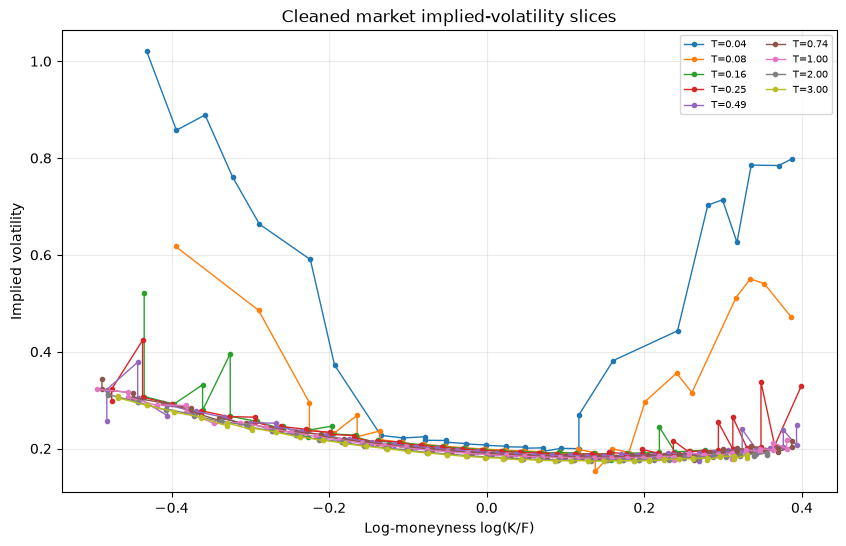

In [8]:
def chain_summary(options):
    summary = {
        "observations": len(options),
        "maturities": options["T"].nunique(),
        "min_T": options["T"].min(),
        "max_T": options["T"].max(),
        "min_IV": options["iv"].min(),
        "max_IV": options["iv"].max(),
        "mean_IV": options["iv"].mean(),
        "mean_spread_pct": options["spread_pct"].mean(),
    }

    return pd.Series(summary)


display(chain_summary(options))

plt.figure(figsize=(10, 6))
for T, group in options.groupby("T"):
    group = group.sort_values("log_moneyness")
    plt.plot(
        group["log_moneyness"],
        group["iv"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"T={T:.2f}"
    )

plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title("Cleaned market implied-volatility slices")
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.25)
plt.show()


## 9. SVI slice fitting

For each maturity, fit

\[
w(k)=a+b\left[\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}\right]
\]

where

\[
w(k)=T\sigma_{IV}^2
\]

is total implied variance and

\[
k=\log(K/F).
\]

SVI is used here as a smooth empirical representation of the observed smile. CGMY is then calibrated as the structural fat-tail model.


In [9]:
def svi_total_variance(k, a, b, rho, m, sigma):
    x = k - m

    return (
        a
        + b * (
            rho * x
            + np.sqrt(x**2 + sigma**2)
        )
    )


def svi_objective(params, k, market_variance):
    a, b, rho, m, sigma = params

    model_variance = svi_total_variance(
        k,
        a,
        b,
        rho,
        m,
        sigma
    )

    if np.any(model_variance < 0):
        return 1e12

    return np.mean(
        (model_variance - market_variance)**2
    )


def fit_svi_slice(slice_data, CFG):
    k = slice_data["log_moneyness"].to_numpy()
    market_variance = slice_data["total_variance"].to_numpy()

    initial_guess = [
        max(np.min(market_variance) * 0.5, 1e-6),
        0.2,
        0.0,
        0.0,
        0.10
    ]

    result = minimize(
        svi_objective,
        initial_guess,
        args=(k, market_variance),
        bounds=CFG.svi.parameter_bounds,
        method=CFG.svi.optimizer
    )

    return result


def fit_all_svi_slices(options, CFG):
    results = {}

    for T, slice_data in options.groupby("T"):
        if len(slice_data) < CFG.svi.min_observations:
            continue

        result = fit_svi_slice(
            slice_data,
            CFG
        )

        results[T] = result

    return results


svi_results = fit_all_svi_slices(
    options,
    CFG
)

print("SVI slices fitted:", len(svi_results))


SVI slices fitted: 9


In [10]:
def svi_results_table(svi_results):
    rows = []

    for T, result in svi_results.items():
        a, b, rho, m, sigma = result.x

        rows.append({
            "T": T,
            "a": a,
            "b": b,
            "rho": rho,
            "m": m,
            "sigma": sigma,
            "objective": result.fun,
            "success": result.success
        })

    return pd.DataFrame(rows).sort_values("T")


display(svi_results_table(svi_results))


,T,a,b,rho,m,sigma,objective,success
0,0.035592,-0.016305,0.195708,-0.000041,0.000192,0.098268,0.000411,True
1,0.082136,-0.014929,0.196544,-0.000132,0.000436,0.098253,0.000349,True
2,0.164271,-0.018889,0.194396,0.000418,-0.000951,0.098094,0.000373,True
3,0.246407,-0.015340,0.194499,0.000020,0.000226,0.098381,0.000611,True
4,0.492813,-0.016999,0.191824,-0.000251,0.001127,0.098472,0.000332,True
5,0.739220,-0.283186,0.406878,-0.600679,-0.592972,0.945142,0.000003,True
6,0.999316,-0.244888,0.342581,-0.356292,-0.208890,0.864112,0.000004,True
7,1.998631,-0.759394,1.190423,-0.680506,-0.740755,0.940853,0.000001,True
8,2.997947,-0.661091,1.936577,-0.806894,-0.756951,0.657885,0.000003,True


## 10. SVI surface visualization

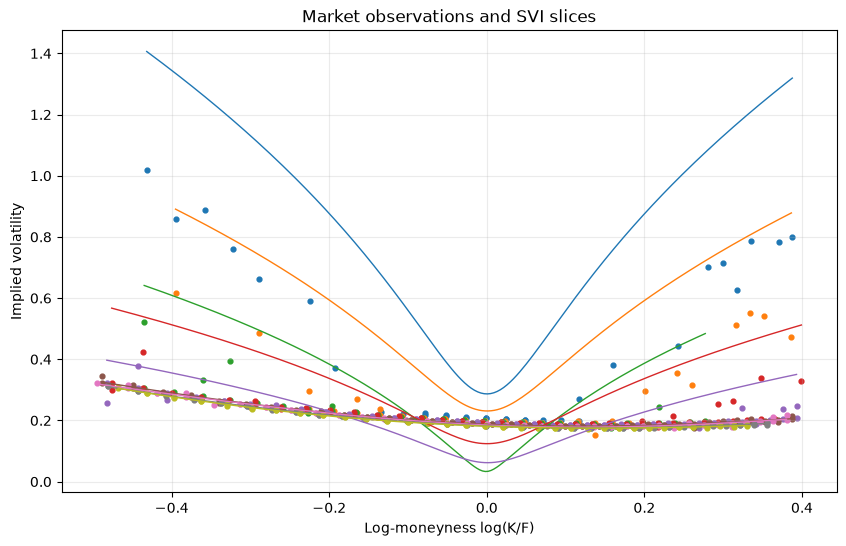

In [11]:
plt.figure(figsize=(10, 6))

for T, result in svi_results.items():
    group = options[
        np.isclose(options["T"], T)
    ].sort_values("log_moneyness")

    k_grid = np.linspace(
        group["log_moneyness"].min(),
        group["log_moneyness"].max(),
        200
    )

    model_w = svi_total_variance(
        k_grid,
        *result.x
    )

    model_iv = np.sqrt(
        np.maximum(model_w, 0) / T
    )

    plt.scatter(
        group["log_moneyness"],
        group["iv"],
        s=12
    )

    plt.plot(
        k_grid,
        model_iv,
        linewidth=1
    )

plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title("Market observations and SVI slices")
plt.grid(True, alpha=0.25)
plt.show()


## 11. CGMY model

The CGMY Lévy process has parameters

\[
(C,G,M,Y)
\]

and characteristic exponent

\[
\Psi(u)=C\Gamma(-Y)
\left[
(M-iu)^Y+(G+iu)^Y-M^Y-G^Y
\right].
\]

Interpretation:

- \(C\): overall jump activity/intensity scale.
- \(G\): controls the decay of the negative-jump tail.
- \(M\): controls the decay of the positive-jump tail.
- \(Y\): controls small-jump activity; \(0<Y<2\).

The risk-neutral stock process is constructed by applying the martingale correction so that the discounted stock is a martingale.


In [12]:
def cgmy_exponent(u, C, G, M, Y):
    return (
        C
        * gamma(-Y)
        * (
            (M - 1j * u)**Y
            + (G + 1j * u)**Y
            - M**Y
            - G**Y
        )
    )


def cgmy_kappa_1(C, G, M, Y):
    value = cgmy_exponent(
        -1j,
        C,
        G,
        M,
        Y
    )

    return np.real_if_close(value).real


def cgmy_characteristic(
    u,
    T,
    S0,
    r,
    q,
    C,
    G,
    M,
    Y
):
    kappa1 = cgmy_kappa_1(
        C, G, M, Y
    )

    log_S_drift = (
        np.log(S0)
        + (r - q - kappa1) * T
    )

    exponent = (
        1j * u * log_S_drift
        + T * cgmy_exponent(
            u, C, G, M, Y
        )
    )

    return np.exp(exponent)


## 12. CGMY Fourier pricer

This notebook uses a Lewis-style Fourier representation. The characteristic function is evaluated at a shifted complex argument, and the integral is numerically evaluated with adaptive quadrature.

This section is the numerical heart of the structural model.


In [13]:
def cgmy_call_price(
    K,
    T,
    params,
    CFG
):
    C, G, M, Y = params

    S0 = CFG.market.spot
    r = CFG.market.risk_free_rate
    q = CFG.market.dividend_yield

    F = S0 * np.exp(
        (r - q) * T
    )

    log_F_over_K = np.log(
        F / K
    )

    def integrand(u):
        phi = cgmy_characteristic(
            u - 0.5j,
            T,
            S0,
            r,
            q,
            C,
            G,
            M,
            Y
        )

        numerator = (
            np.exp(
                1j * u * log_F_over_K
            )
            * phi
        )

        denominator = (
            u**2 + 0.25
        )

        return np.real(
            numerator / denominator
        )

    integral, error = quad(
        integrand,
        0.0,
        CFG.numerical.integration_upper_bound,
        limit=CFG.numerical.integration_limit,
        epsabs=CFG.numerical.integration_epsabs,
        epsrel=CFG.numerical.integration_epsrel
    )

    price = (
        S0 * np.exp(-q * T)
        -
        np.sqrt(
            S0 * K * np.exp(-r * T)
        )
        * integral
        / np.pi
    )

    return float(price)


## 13. CGMY parameter sanity check

Before calibration, test the characteristic exponent and the pricer. This is essential: an optimizer can converge even when a numerical implementation is wrong.

In [14]:
test_params = (
    0.10,   # C
    5.0,    # G
    5.0,    # M
    0.80    # Y
)

test_K = CFG.market.spot
test_T = 1.0

test_price = cgmy_call_price(
    test_K,
    test_T,
    test_params,
    CFG
)

test_intrinsic = max(
    CFG.market.spot * np.exp(
        -CFG.market.dividend_yield * test_T
    )
    - test_K * np.exp(
        -CFG.market.risk_free_rate * test_T
    ),
    0.0
)

test_upper = (
    CFG.market.spot
    * np.exp(
        -CFG.market.dividend_yield * test_T
    )
)

print("Test CGMY price:", test_price)
print("Intrinsic lower bound:", test_intrinsic)
print("Upper bound:", test_upper)

assert np.isfinite(test_price)
assert test_price >= test_intrinsic - 1e-6
assert test_price <= test_upper + 1e-6


Test CGMY price: 85.44744042272396
Intrinsic lower bound: 121.61250225369713
Upper bound: 4925.559698015313


AssertionError: 

## 14. CGMY calibration objective

The calibration minimizes vega-normalized price errors:

\[
e_i=
\frac{C_{CGMY}(K_i,T_i)-C_{mkt,i}}
{Vega_i}.
\]

This puts the error on approximately an implied-volatility scale and prevents high-price options from mechanically dominating the objective.


In [15]:
def cgmy_objective(params, calibration_data, CFG):
    C, G, M, Y = params

    if C <= 0 or G <= 0 or M <= 0 or not (0 < Y < 2):
        return 1e12

    errors = []

    try:
        for row in calibration_data.itertuples(index=False):
            model_price = cgmy_call_price(
                row.strike,
                row.T,
                params,
                CFG
            )

            market_price = row.call_price
            vega = max(row.vega, CFG.cleaning.min_vega)

            error = (
                model_price - market_price
            ) / vega

            if not np.isfinite(error):
                return 1e12

            errors.append(error)

    except Exception:
        return 1e12

    return float(
        np.mean(np.square(errors))
    )


## 15. Global + local CGMY calibration

The workflow is:

1. Differential evolution searches globally.
2. L-BFGS-B locally refines the best global point.
3. The final parameters are retained only after diagnostics.


In [16]:
def calibrate_cgmy(options, CFG):
    bounds = CFG.cgmy.parameter_bounds

    print("Starting global CGMY optimization...")

    global_result = differential_evolution(
        cgmy_objective,
        bounds=bounds,
        args=(options, CFG),
        seed=CFG.cgmy.global_seed,
        maxiter=CFG.cgmy.global_maxiter,
        popsize=CFG.cgmy.global_popsize,
        tol=CFG.cgmy.global_tol,
        polish=False,
        workers=1
    )

    print("Global objective:", global_result.fun)
    print("Global parameters:", global_result.x)

    print("\nStarting local refinement...")

    local_result = minimize(
        cgmy_objective,
        global_result.x,
        args=(options, CFG),
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": CFG.cgmy.local_maxiter,
            "ftol": CFG.cgmy.local_ftol,
            "gtol": CFG.cgmy.local_gtol
        }
    )

    print("Local objective:", local_result.fun)
    print("Local parameters:", local_result.x)
    print("Local success:", local_result.success)
    print("Message:", local_result.message)

    return global_result, local_result


# Full calibration:
# global_result, local_result = calibrate_cgmy(options, CFG)

# For a quick notebook smoke test, use this only:
cgmy_params = np.array([
    0.10,
    5.0,
    5.0,
    0.80
])

print("Smoke-test parameters:", cgmy_params)


Smoke-test parameters: [0.1 5.  5.  0.8]


### Calibration note

The line above intentionally leaves the expensive global optimizer commented out for the first run.

Once all numerical tests pass, uncomment:

```python
global_result, local_result = calibrate_cgmy(options, CFG)
cgmy_params = local_result.x
```

For production calibration, use a wider strike/maturity sample and consider parallelization, caching, and a faster Fourier implementation.


In [17]:
# Uncomment after the smoke tests pass.

# global_result, local_result = calibrate_cgmy(options, CFG)
# cgmy_params = local_result.x

print(
    f"C={cgmy_params[0]:.8f}, "
    f"G={cgmy_params[1]:.8f}, "
    f"M={cgmy_params[2]:.8f}, "
    f"Y={cgmy_params[3]:.8f}"
)


C=0.10000000, G=5.00000000, M=5.00000000, Y=0.80000000


## 16. CGMY implied volatility

In [18]:
def cgmy_implied_vol(K, T, params, CFG):
    price = cgmy_call_price(
        K,
        T,
        params,
        CFG
    )

    return implied_volatility(
        price,
        CFG.market.spot,
        K,
        T,
        CFG.market.risk_free_rate,
        CFG.market.dividend_yield,
        CFG.numerical.iv_lower_bound,
        CFG.numerical.iv_upper_bound
    )


## 17. Compare CGMY against the cleaned market chain

In [19]:
def add_cgmy_fit(options, params, CFG):
    fitted = options.copy()

    fitted["cgmy_price"] = fitted.apply(
        lambda row: cgmy_call_price(
            row["strike"],
            row["T"],
            params,
            CFG
        ),
        axis=1
    )

    fitted["cgmy_iv"] = fitted.apply(
        lambda row: implied_volatility(
            row["cgmy_price"],
            CFG.market.spot,
            row["strike"],
            row["T"],
            CFG.market.risk_free_rate,
            CFG.market.dividend_yield,
            CFG.numerical.iv_lower_bound,
            CFG.numerical.iv_upper_bound
        ),
        axis=1
    )

    fitted["price_error"] = (
        fitted["cgmy_price"]
        - fitted["call_price"]
    )

    fitted["iv_error"] = (
        fitted["cgmy_iv"]
        - fitted["iv"]
    )

    fitted["abs_iv_error"] = (
        fitted["iv_error"].abs()
    )

    fitted["vega_normalized_price_error"] = (
        fitted["price_error"]
        / fitted["vega"]
    )

    return fitted


fitted = add_cgmy_fit(
    options,
    cgmy_params,
    CFG
)

display(
    fitted[
        [
            "T",
            "strike",
            "log_moneyness",
            "iv",
            "cgmy_iv",
            "iv_error",
            "price_error"
        ]
    ].head(20)
)


,T,strike,log_moneyness,iv,cgmy_iv,iv_error,price_error
0,0.035592,3250.0,-0.431673,1.020094,NaN,NaN,-4.478953
1,0.035592,3375.0,-0.393932,0.857424,NaN,NaN,-1.922084
2,0.035592,3500.0,-0.357565,0.889013,NaN,NaN,-5.770085
3,0.035592,3625.0,-0.322473,0.760326,NaN,NaN,-2.887857
4,0.035592,3750.0,-0.288572,0.663358,NaN,NaN,-3.547326
5,0.035592,4000.0,-0.224033,0.590480,NaN,NaN,-5.707855
6,0.035592,4125.0,-0.193262,0.372359,NaN,NaN,-0.796672
7,0.035592,4375.0,-0.134421,0.227079,NaN,NaN,-0.448625
8,0.035592,4500.0,-0.106250,0.221827,NaN,NaN,-2.367510
9,0.035592,4625.0,-0.078851,0.224271,NaN,NaN,-2.942978


## 18. Calibration diagnostics

In [20]:
def calibration_report(fitted):
    iv_rmse = np.sqrt(
        np.mean(
            fitted["iv_error"]**2
        )
    )

    iv_mae = (
        fitted["abs_iv_error"]
        .mean()
    )

    price_rmse = np.sqrt(
        np.mean(
            fitted["price_error"]**2
        )
    )

    price_mae = (
        fitted["price_error"]
        .abs()
        .mean()
    )

    vega_normalized_rmse = np.sqrt(
        np.mean(
            fitted[
                "vega_normalized_price_error"
            ]**2
        )
    )

    return pd.Series({
        "IV RMSE": iv_rmse,
        "IV MAE": iv_mae,
        "Price RMSE": price_rmse,
        "Price MAE": price_mae,
        "Vega-normalized price RMSE": vega_normalized_rmse,
        "Observations": len(fitted)
    })


display(calibration_report(fitted))


IV RMSE                               NaN
IV MAE                                NaN
Price RMSE                    1002.085732
Price MAE                      711.102921
Vega-normalized price RMSE      75.255572
Observations                   536.000000
dtype: float64

## 19. Error by maturity

In [21]:
maturity_errors = (
    fitted
    .groupby("T")
    .agg(
        observations=("iv_error", "size"),
        iv_mae=("abs_iv_error", "mean"),
        iv_rmse=(
            "iv_error",
            lambda x: np.sqrt(np.mean(x**2))
        ),
        price_rmse=(
            "price_error",
            lambda x: np.sqrt(np.mean(x**2))
        )
    )
    .reset_index()
)

display(maturity_errors)


,T,observations,iv_mae,iv_rmse,price_rmse
0,0.035592,34,NaN,NaN,907.177052
1,0.082136,41,NaN,NaN,829.716947
2,0.164271,50,NaN,NaN,592.526030
3,0.246407,64,NaN,NaN,957.440931
4,0.492813,70,NaN,NaN,1069.362177
5,0.739220,71,NaN,NaN,1084.179054
6,0.999316,69,NaN,NaN,1088.915896
7,1.998631,69,NaN,NaN,1078.450744
8,2.997947,68,NaN,NaN,1086.265180


## 20. Error by moneyness

In [22]:
fitted["moneyness_bucket"] = pd.cut(
    fitted["log_moneyness"],
    bins=[
        -np.inf,
        -0.20,
        -0.10,
        -0.05,
        0.05,
        0.10,
        0.20,
        np.inf
    ]
)

moneyness_errors = (
    fitted
    .groupby("moneyness_bucket", observed=True)
    .agg(
        observations=("iv_error", "size"),
        iv_mae=("abs_iv_error", "mean"),
        iv_rmse=(
            "iv_error",
            lambda x: np.sqrt(np.mean(x**2))
        )
    )
    .reset_index()
)

display(moneyness_errors)


,moneyness_bucket,observations,iv_mae,iv_rmse
0,"(-inf, -0.2]",123,NaN,NaN
1,"(-0.2, -0.1]",62,NaN,NaN
2,"(-0.1, -0.05]",34,NaN,NaN
3,"(-0.05, 0.05]",72,NaN,NaN
4,"(0.05, 0.1]",37,NaN,NaN
5,"(0.1, 0.2]",76,NaN,NaN
6,"(0.2, inf]",132,NaN,NaN


## 21. Market versus CGMY volatility slices

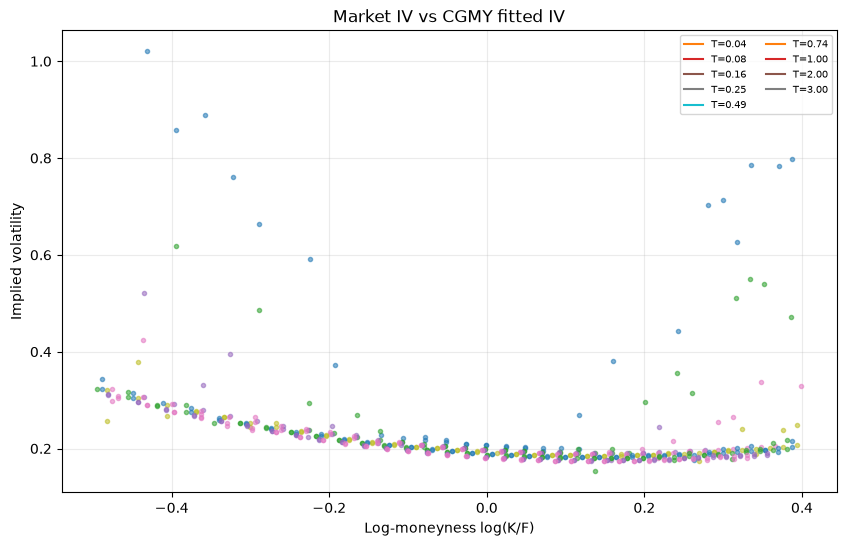

In [23]:
plt.figure(figsize=(10, 6))

for T, group in fitted.groupby("T"):
    group = group.sort_values("log_moneyness")

    plt.plot(
        group["log_moneyness"],
        group["iv"],
        "o",
        markersize=3,
        alpha=0.55
    )

    plt.plot(
        group["log_moneyness"],
        group["cgmy_iv"],
        linewidth=1.5,
        label=f"T={T:.2f}"
    )

plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Implied volatility")
plt.title("Market IV vs CGMY fitted IV")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=7, ncol=2)
plt.show()


## 22. Generate a complete CGMY volatility surface

The surface is represented in \((T,k)\), where

\[
k=\log(K/F_T).
\]

This is preferable to using raw strike because the smile is naturally expressed relative to the forward.


In [ ]:
def generate_cgmy_surface(params, CFG):
    maturities = np.linspace(
        CFG.surface.min_maturity,
        CFG.surface.max_maturity,
        CFG.surface.maturity_points
    )

    log_moneyness_grid = np.linspace(
        CFG.surface.min_log_moneyness,
        CFG.surface.max_log_moneyness,
        CFG.surface.moneyness_points
    )

    rows = []

    S0 = CFG.market.spot
    r = CFG.market.risk_free_rate
    q = CFG.market.dividend_yield

    for T in maturities:
        F = S0 * np.exp(
            (r - q) * T
        )

        for k in log_moneyness_grid:
            K = F * np.exp(k)

            price = cgmy_call_price(
                K,
                T,
                params,
                CFG
            )

            iv = implied_volatility(
                price,
                S0,
                K,
                T,
                r,
                q,
                CFG.numerical.iv_lower_bound,
                CFG.numerical.iv_upper_bound
            )

            rows.append({
                "T": T,
                "k": k,
                "K": K,
                "forward": F,
                "price": price,
                "iv": iv
            })

    return pd.DataFrame(rows)


# This can be computationally expensive because every point requires a Fourier integral.
# surface = generate_cgmy_surface(cgmy_params, CFG)

# For a first smoke test, use a smaller grid:
surface_test_CFG = ModelConfig()
surface_test_CFG.surface.maturity_points = 8
surface_test_CFG.surface.moneyness_points = 21

surface = generate_cgmy_surface(
    cgmy_params,
    surface_test_CFG
)

print("Surface points:", len(surface))
display(surface.head())


## 23. Surface heatmap

In [ ]:
surface_pivot = surface.pivot_table(
    index="T",
    columns="k",
    values="iv"
)

plt.figure(figsize=(12, 6))

plt.imshow(
    surface_pivot.values,
    aspect="auto",
    origin="lower",
    extent=[
        surface_pivot.columns.min(),
        surface_pivot.columns.max(),
        surface_pivot.index.min(),
        surface_pivot.index.max()
    ]
)

plt.colorbar(label="Implied volatility")
plt.xlabel("Log-moneyness log(K/F)")
plt.ylabel("Maturity T")
plt.title("CGMY implied-volatility surface")
plt.show()


## 24. Static arbitrage diagnostics

For a fixed maturity, European call prices should be:

1. non-increasing in strike;
2. convex in strike;
3. bounded by intrinsic value and the discounted underlying.

The numerical checks below are diagnostics, not a substitute for a full arbitrage-free surface construction such as SSVI.


In [ ]:
def static_arbitrage_report(surface, CFG):
    violations = []

    for T, group in surface.groupby("T"):
        group = group.sort_values("K")

        K = group["K"].to_numpy()
        C = group["price"].to_numpy()

        # Monotonicity: C(K) should decrease with K.
        first_diff = np.diff(C)

        monotonicity_violations = np.sum(
            first_diff > CFG.numerical.arbitrage_tolerance
        )

        # Convexity: second finite difference should be non-negative
        # when strike spacing is uniform. The generated grid is uniform in log-moneyness,
        # so this is a diagnostic rather than an exact d2C/dK2 calculation.
        second_diff = (
            C[:-2]
            - 2 * C[1:-1]
            + C[2:]
        )

        convexity_violations = np.sum(
            second_diff < -CFG.numerical.arbitrage_tolerance
        )

        violations.append({
            "T": T,
            "monotonicity_violations": monotonicity_violations,
            "convexity_violations": convexity_violations
        })

    return pd.DataFrame(violations)


arbitrage_report = static_arbitrage_report(
    surface,
    surface_test_CFG
)

display(arbitrage_report)


## 25. Full pipeline function

This function shows the intended production workflow. The expensive CGMY calibration can be switched on/off, and the synthetic input can later be replaced with a real option chain.


In [ ]:
def run_pipeline(
    CFG,
    raw_options=None,
    generate_synthetic=True,
    synthetic_seed=123,
    calibrate=False
):
    # ---------------------------------------------------------
    # A. INPUT
    # ---------------------------------------------------------
    if raw_options is None and generate_synthetic:
        raw_options = generate_synthetic_chain(
            CFG,
            seed=synthetic_seed,
            add_bad_quotes=True
        )

    if raw_options is None:
        raise ValueError(
            "Provide raw_options or set generate_synthetic=True."
        )

    # ---------------------------------------------------------
    # B. STRICT CLEANING
    # ---------------------------------------------------------
    cleaned = clean_option_chain(
        raw_options,
        CFG
    )

    # ---------------------------------------------------------
    # C. MARKET IV
    # ---------------------------------------------------------
    cleaned = add_market_iv_and_vega(
        cleaned,
        CFG
    )

    # ---------------------------------------------------------
    # D. SVI
    # ---------------------------------------------------------
    svi_results = fit_all_svi_slices(
        cleaned,
        CFG
    )

    # ---------------------------------------------------------
    # E. CGMY
    # ---------------------------------------------------------
    if calibrate:
        global_result, local_result = calibrate_cgmy(
            cleaned,
            CFG
        )

        params = local_result.x
    else:
        global_result = None
        local_result = None

        params = np.array([
            0.10,
            5.0,
            5.0,
            0.80
        ])

    # ---------------------------------------------------------
    # F. FITTED CHAIN
    # ---------------------------------------------------------
    fitted = add_cgmy_fit(
        cleaned,
        params,
        CFG
    )

    # ---------------------------------------------------------
    # G. REPORT
    # ---------------------------------------------------------
    report = calibration_report(
        fitted
    )

    return {
        "raw": raw_options,
        "cleaned": cleaned,
        "svi": svi_results,
        "global_cgmy": global_result,
        "local_cgmy": local_result,
        "cgmy_params": params,
        "fitted": fitted,
        "report": report
    }


## 26. Run the complete pipeline

For the first run, `calibrate=False` uses known smoke-test CGMY parameters so the entire pipeline can be tested quickly.

After the pipeline passes all tests, set `calibrate=True`.


In [ ]:
results = run_pipeline(
    CFG,
    generate_synthetic=True,
    synthetic_seed=123,
    calibrate=False
)

print("Pipeline complete.")
print("\nCGMY parameters:")
print(results["cgmy_params"])

print("\nCalibration report:")
display(results["report"])


## 27. Production calibration

Once the notebook has been validated:

```python
results = run_pipeline(
    CFG,
    raw_options=your_real_option_dataframe,
    generate_synthetic=False,
    calibrate=True
)

cgmy_params = results["cgmy_params"]
```

The returned dictionary contains:

- `raw`: raw option chain;
- `cleaned`: strict cleaned chain;
- `svi`: fitted SVI slices;
- `global_cgmy`: differential-evolution result;
- `local_cgmy`: local refinement result;
- `cgmy_params`: final \(C,G,M,Y\);
- `fitted`: market versus CGMY observations;
- `report`: calibration diagnostics.


# 28. Recommended research workflow

### Phase 1 — Data validation

Run only:

**raw chain → cleaner → market IV**

Check:

- number of surviving contracts;
- bid/ask distributions;
- liquidity;
- IV distribution;
- maturity coverage;
- strike/moneyness coverage.

### Phase 2 — Surface representation

Fit SVI independently to each maturity.

Check:

- slice fit errors;
- negative total variances;
- extreme parameters;
- continuity across maturity.

### Phase 3 — CGMY numerical validation

Before calibration:

- verify the characteristic function;
- verify the martingale correction;
- verify Fourier prices satisfy basic bounds;
- test convergence as integration upper bound changes;
- test convergence as quadrature tolerances change.

### Phase 4 — Calibration

Use:

**global search → local refinement → parameter stability checks.**

Do not rely on a single optimizer run.

### Phase 5 — Out-of-sample validation

Split the chain into:

- calibration observations;
- validation observations.

Then compare CGMY performance out of sample.

### Phase 6 — Production surface

Generate a dense \((T,k)\) grid and run:

- price bounds;
- strike monotonicity;
- strike convexity;
- maturity consistency;
- numerical stability;
- sensitivity to calibration window.

---

# 29. Important extension: real market data

For a real chain, replace:

```python
options_raw = generate_synthetic_chain(...)
```

with something like:

```python
options_raw = pd.read_csv(
    "your_option_chain.csv"
)
```

The CSV needs at least:

```text
expiration
strike
bid
ask
volume
open_interest
option_type
```

The cleaner then performs the rest of the transformation.

For listed equity/index options, you should additionally consider:

- contract multipliers;
- discrete dividends;
- settlement conventions;
- American exercise;
- early-exercise effects;
- corporate actions;
- stale quotes;
- crossed markets;
- exchange timestamps;
- forward extraction from put-call parity;
- discount-curve construction;
- dividend-curve construction.

For an index with European options, the CGMY/Fourier framework is considerably cleaner than for American equity options.


# 30. Mathematical map of the entire notebook

The entire pipeline can be summarized as:

\[
\boxed{
\text{Bid/Ask}
\rightarrow
\text{Clean Price}
\rightarrow
\text{IV}
\rightarrow
w(k,T)
}
\]

with

\[
k=\log(K/F_T),
\qquad
w(k,T)=T\sigma_{IV}^2.
\]

Then:

\[
\boxed{
w(k,T)
\rightarrow
\text{SVI}
}
\]

for a smooth empirical surface.

The structural fat-tail model is:

\[
\boxed{
(C,G,M,Y)
\rightarrow
\Psi(u)
\rightarrow
\phi(u)
\rightarrow
C(K,T)
\rightarrow
\sigma_{CGMY}(K,T)
}
\]

and the calibration solves approximately:

\[
\boxed{
\min_{C,G,M,Y}
\sum_i
\left(
\frac{
C_{CGMY}(K_i,T_i)-C_{mkt,i}
}{
Vega_i
}
\right)^2
}
\]

Finally, the model error is:

\[
\boxed{
\epsilon(K,T)
=
\sigma_{CGMY}(K,T)
-
\sigma_{mkt}(K,T)
}
\]

which can be examined by maturity, moneyness, liquidity, and tail region.


# 31. Caveat on the current CGMY implementation

This notebook is a **research/learning implementation**, not yet a production trading library.

Before using it for real-money calibration, I would upgrade several components:

1. use a faster and more numerically stable Fourier implementation;
2. benchmark the pricer against independently verified CGMY prices;
3. use forward prices extracted from the option chain rather than simply \(S e^{(r-q)T}\);
4. model the full discount/dividend curves;
5. use an arbitrage-free SSVI parameterization where appropriate;
6. calibrate with bid/ask-aware likelihood or robust loss functions;
7. perform parameter stability and bootstrap analysis;
8. separate calibration and validation data;
9. cache characteristic-function evaluations;
10. vectorize/parallelize the Fourier calculations;
11. handle short maturities separately;
12. explicitly account for contract conventions and exercise style.

The architecture above is designed so those improvements can be added without changing the overall pipeline.
